# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [1]:
# Carregando todas as bibliotecas

import pandas as pd
import numpy as np
from scipy import stats as st
import warnings
import math
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv('/datasets/megaline_users.csv') # Dados sobre os usuários
df_calls = pd.read_csv('/datasets/megaline_calls.csv') # Dados sobre as chamadas
df_messages = pd.read_csv('/datasets/megaline_messages.csv') # Dados sobre mensagens de texto
df_internet = pd.read_csv('/datasets/megaline_internet.csv') # Dados sobre sessões web
df_plans = pd.read_csv('/datasets/megaline_plans.csv') # Dados sobre os planos

## Prepare os dados

In [3]:
# Função que faz um resumo geral de cada DataFrame
def summary (data):
    consult = pd.DataFrame({
        'type': data.dtypes,#Tipo de cada coluna
        'missing': data.isna().sum(),#Quantidade de valores nulos em cada coluna
        'size': data.shape[0],#Quantidade de linhas
        'unique':data.nunique()#Qantidade de valores unicos
    })
    return consult

### Conhecendo o DataFrame df_users

In [4]:
summary(df_users)

,type,missing,size,unique
user_id,int64,0,500,500
first_name,object,0,500,458
last_name,object,0,500,399
age,int64,0,500,58
city,object,0,500,73
reg_date,object,0,500,266
plan,object,0,500,2
churn_date,object,466,500,29


In [5]:
df_users['plan'].value_counts()

surf        339
ultimate    161
Name: plan, dtype: int64

In [6]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [7]:
df_users.duplicated().sum()

0

Observações:

* 34 pessoas encerram o contrato
* 339 pessoas assinaram o plano surf
* 161 pessoas assinaram o plano ultimate
* Não há dados duplicados explicitos

### Conhecendo o DataFrame df_calls

In [8]:
df_calls.info()
df_calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [9]:
df_calls.duplicated().sum()

0


Observações:

* Não há valores nulos
* Não há valores explicitos duplicados


### Conhecendo o DataFrame df_messages

In [10]:
df_messages.info()
df_messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [11]:
df_messages.duplicated().sum()

0

Observações:

* Não há valores nulos
* Não há valores explicitos duplicados

### Conhecendo o DataFrame df_internet

In [12]:
df_internet.info()
df_internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Observações:

* Não há valores nulos
* Não há valores explicitos duplicados
* A coluna mb_used usa a unidade megabytes

### Conhecendo o DataFrame df_plans

In [13]:
df_plans.info()
df_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Observações:

* Não há valores nulos
* Não há valores explicitos duplicados
* A coluna mb_per_month_included usa a unidade megabytes
* O indice poderia ser o nome do plano

## Planos

In [14]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [15]:
# Imprima uma amostra de dados dos planos
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Análisando o df_plans percibi que seria interessante alterar o índice para o nome dos planos e alterar os dados da coluna mb_per_month_included para GB, no qual 1GB=1024mb

### Corrija os dados

In [16]:
# Alterando o índice do df_plans para o nome dos planos
df_plans.set_index('plan_name', inplace=True)

# Alterando os dados da coluna mb_per_month_included para GB
df_plans['mb_per_month_included'] = df_plans['mb_per_month_included']/1024

# Alterando o nome da coluna mb_per_month_included para gb_per_month_included
df_plans.rename(columns={'mb_per_month_included':'gb_per_month_included'}, inplace=True)


In [17]:
df_plans

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
plan_name,,,,,,,
surf,50,15.0,500,20,10,0.03,0.03
ultimate,1000,30.0,3000,70,7,0.01,0.01


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

## Usuários

In [18]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [19]:
# Imprima uma amostra de dados dos usuários
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


* Alterar o tipo das colunas reg_date e churn_date
* Colocar a coluna city toda em minusculo
* Alterar espaços para '_' na coluna city

### Corrija os dados

In [20]:
#Alterando o tipo das colunas reg_date e churn_date para datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

#Tirar espaços e colocar '_' e colocar tudo em minusculo na coluna city
df_users['city'] = df_users['city'].str.lower()
df_users['city'] = df_users['city'].str.replace(' ','_')

In [21]:
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"atlanta-sandy_springs-roswell,_ga_msa",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"seattle-tacoma-bellevue,_wa_msa",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"las_vegas-henderson-paradise,_nv_msa",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"tulsa,_ok_msa",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"seattle-tacoma-bellevue,_wa_msa",2018-05-23,surf,NaT
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"new_york-newark-jersey_city,_ny-nj-pa_msa",2018-09-04,surf,NaT
496,1496,Ariel,Shepherd,49,"new_orleans-metairie,_la_msa",2018-02-20,surf,NaT
497,1497,Donte,Barrera,49,"los_angeles-long_beach-anaheim,_ca_msa",2018-12-10,ultimate,NaT
498,1498,Scot,Williamson,51,"new_york-newark-jersey_city,_ny-nj-pa_msa",2018-02-04,surf,NaT


### Enriqueça os dados

In [22]:
#Criar coluna de mês de registro dos clientes
df_users['reg_month'] = df_users['reg_date'].dt.month

#Criar coluna para saber quantos dias o cliente contratou algum serviço
df_users['period_of_stay'] = (df_users['churn_date'] - df_users['reg_date'])

In [23]:
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,period_of_stay
0,1000,Anamaria,Bauer,45,"atlanta-sandy_springs-roswell,_ga_msa",2018-12-24,ultimate,NaT,12,NaT
1,1001,Mickey,Wilkerson,28,"seattle-tacoma-bellevue,_wa_msa",2018-08-13,surf,NaT,8,NaT
2,1002,Carlee,Hoffman,36,"las_vegas-henderson-paradise,_nv_msa",2018-10-21,surf,NaT,10,NaT
3,1003,Reynaldo,Jenkins,52,"tulsa,_ok_msa",2018-01-28,surf,NaT,1,NaT
4,1004,Leonila,Thompson,40,"seattle-tacoma-bellevue,_wa_msa",2018-05-23,surf,NaT,5,NaT
...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"new_york-newark-jersey_city,_ny-nj-pa_msa",2018-09-04,surf,NaT,9,NaT
496,1496,Ariel,Shepherd,49,"new_orleans-metairie,_la_msa",2018-02-20,surf,NaT,2,NaT
497,1497,Donte,Barrera,49,"los_angeles-long_beach-anaheim,_ca_msa",2018-12-10,ultimate,NaT,12,NaT
498,1498,Scot,Williamson,51,"new_york-newark-jersey_city,_ny-nj-pa_msa",2018-02-04,surf,NaT,2,NaT


## Chamadas

In [24]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [25]:
# Imprima uma amostra de dados das chamadas
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


É necessário fazer a alteração do tipo da coluna call_date e arredondar os valores da coluna duration para cima.

### Corrija os dados

In [26]:
#Alterando o tipo da coluna call_date para datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

#Arredondar os valores da coluna duration
df_calls['duration'] = np.ceil(df_calls['duration'])

In [27]:
df_calls

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0
...,...,...,...,...
137730,1499_199,1499,2018-11-21,9.0
137731,1499_200,1499,2018-10-20,11.0
137732,1499_201,1499,2018-09-21,9.0
137733,1499_202,1499,2018-10-10,1.0


### Enriqueça os dados

In [28]:
#Criar coluna com o mês das ligações
df_calls['month'] = df_calls['call_date'].dt.month
df_calls

,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,9.0,12
1,1000_145,1000,2018-12-27,14.0,12
2,1000_247,1000,2018-12-27,15.0,12
3,1000_309,1000,2018-12-28,6.0,12
4,1000_380,1000,2018-12-30,5.0,12
...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,9.0,11
137731,1499_200,1499,2018-10-20,11.0,10
137732,1499_201,1499,2018-09-21,9.0,9
137733,1499_202,1499,2018-10-10,1.0,10


## Mensagens

In [29]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [30]:
# Imprima uma amostra dos dados das mensagens
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


É necessário fazer a alteração do tipo da coluna message_date.

### Corrija os dados

In [31]:
#Alterando o tipo da coluna message_date para datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

### Enriqueça os dados

In [32]:
#Criar coluna com o mês das mensagens
df_messages['month'] = df_messages['message_date'].dt.month
df_messages

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12
...,...,...,...,...
76046,1497_526,1497,2018-12-24,12
76047,1497_536,1497,2018-12-24,12
76048,1497_547,1497,2018-12-31,12
76049,1497_558,1497,2018-12-24,12


## Internet

In [33]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [34]:
#  Imprima uma amostra de dados para o tráfego da internet
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Alterar o tipo da coluna session_date para datetime e alterar a unidade de medida da coluna mb_used.

### Corrija os dados

In [35]:
#Alterando o tipo da coluna message_date para datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

#Converter a unidade da coluna mb_used para GB
df_internet['mb_used'] = df_internet['mb_used']/1024

#Criar uma coluna com valor arredondado
df_internet['gb_used'] = np.ceil(df_internet['mb_used'])

#Apagar coluna mb_used
df_internet = df_internet.drop('mb_used', axis=1)

### Enriqueça os dados

In [36]:
#Criar coluna com o mês das mensagens
df_internet['month'] = df_internet['session_date'].dt.month

df_internet

,id,user_id,session_date,gb_used,month
0,1000_13,1000,2018-12-29,1.0,12
1,1000_204,1000,2018-12-31,0.0,12
2,1000_379,1000,2018-12-28,1.0,12
3,1000_413,1000,2018-12-26,1.0,12
4,1000_442,1000,2018-12-27,1.0,12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,1.0,10
104821,1499_216,1499,2018-12-30,1.0,12
104822,1499_217,1499,2018-09-22,1.0,9
104823,1499_218,1499,2018-12-07,0.0,12


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [37]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
df_plans

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
plan_name,,,,,,,
surf,50,15.0,500,20,10,0.03,0.03
ultimate,1000,30.0,3000,70,7,0.01,0.01


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [38]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
df_calls_filter_by_user = df_calls.groupby(by=['user_id','month']).count().reset_index()
df_calls_filter_by_user = df_calls_filter_by_user.rename(columns={'id':'amount_calls'}).drop(columns=['call_date','duration'], axis=1).sort_values(by=['user_id','month'])
df_calls_filter_by_user

,user_id,month,amount_calls
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
...,...,...,...
2253,1498,12,39
2254,1499,9,41
2255,1499,10,53
2256,1499,11,45


In [39]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
df_calls_filter_by_user_duration = df_calls.groupby(by=['user_id','month']).sum().reset_index()
df_calls_filter_by_user_duration = df_calls_filter_by_user_duration.rename(columns={'duration':'total_duration'}).sort_values(by=['user_id','month'])
df_calls_filter_by_user_duration

,user_id,month,total_duration
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0
...,...,...,...
2253,1498,12,339.0
2254,1499,9,346.0
2255,1499,10,385.0
2256,1499,11,308.0


In [40]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
df_messages_filter_by_user = df_messages.groupby(by=['user_id','month']).count().reset_index()
df_messages_filter_by_user = df_messages_filter_by_user.drop(columns='message_date').rename(columns={'id':'amount_messages'}).sort_values(by=['user_id','month'])
df_messages_filter_by_user

,user_id,month,amount_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [41]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
df_internet_filter_by_user = df_internet.groupby(by=['user_id','month']).sum().reset_index()
df_internet_filter_by_user

,user_id,month,gb_used
0,1000,12,4.0
1,1001,8,21.0
2,1001,9,41.0
3,1001,10,50.0
4,1001,11,49.0
...,...,...,...
2272,1498,12,56.0
2273,1499,9,37.0
2274,1499,10,52.0
2275,1499,11,43.0


In [42]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_agreed = pd.merge(df_calls_filter_by_user, df_calls_filter_by_user_duration, on=['user_id','month'], how='outer')
df_agreed = df_agreed.fillna(0)

df_agreed_1 = pd.merge(df_messages_filter_by_user, df_internet_filter_by_user, on=['user_id','month'], how='outer')
df_agreed_1 = df_agreed_1.fillna(0)

df_agreed_2 = pd.merge(df_agreed, df_agreed_1, on=['user_id','month'])
df_agreed_2 = df_agreed_2.fillna(0)

In [43]:
# Adicione as informações sobre o plano
filter_by_plan = df_users[['user_id', 'plan','city']]

df_agreed_3 = pd.merge(df_agreed_2,filter_by_plan, on='user_id', how='outer')
df_agreed_3 = df_agreed_3.fillna(0)

[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [44]:
df_agreed_4 = pd.merge(df_agreed_3, df_plans, left_on='plan', right_on='plan_name', how='outer')
df_agreed_4 = df_agreed_4.fillna(0)

In [45]:
# Calculando a diferença de mensagens envidas por usuário por mês
df_agreed_4['diference_messages'] = df_agreed_4['messages_included'] - df_agreed_4['amount_messages']

# Calculando a diferença de minutos utilizados por usuário por mês
df_agreed_4['diference_minutes'] = df_agreed_4['minutes_included'] - df_agreed_4['total_duration']

# Calculando a diferença de dados utilizados por usuário por mês
df_agreed_4['diference_dados'] = df_agreed_4['gb_per_month_included'] - df_agreed_4['gb_used']

# Imprimir DF
df_agreed_4

,user_id,month,amount_calls,total_duration,amount_messages,gb_used,plan,city,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,diference_messages,diference_minutes,diference_dados
0,1000,12.0,16.0,124.0,11.0,4.0,ultimate,"atlanta-sandy_springs-roswell,_ga_msa",1000,30.0,3000,70,7,0.01,0.01,989.0,2876.0,26.0
1,1006,11.0,2.0,10.0,15.0,7.0,ultimate,"san_francisco-oakland-berkeley,_ca_msa",1000,30.0,3000,70,7,0.01,0.01,985.0,2990.0,23.0
2,1006,12.0,9.0,59.0,139.0,62.0,ultimate,"san_francisco-oakland-berkeley,_ca_msa",1000,30.0,3000,70,7,0.01,0.01,861.0,2941.0,-32.0
3,1008,10.0,71.0,476.0,21.0,48.0,ultimate,"orlando-kissimmee-sanford,_fl_msa",1000,30.0,3000,70,7,0.01,0.01,979.0,2524.0,-18.0
4,1008,11.0,63.0,446.0,37.0,56.0,ultimate,"orlando-kissimmee-sanford,_fl_msa",1000,30.0,3000,70,7,0.01,0.01,963.0,2554.0,-26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,1307,0.0,0.0,0.0,0.0,0.0,surf,"boston-cambridge-newton,_ma-nh_msa",50,15.0,500,20,10,0.03,0.03,50.0,500.0,15.0
2272,1319,0.0,0.0,0.0,0.0,0.0,surf,"colorado_springs,_co_msa",50,15.0,500,20,10,0.03,0.03,50.0,500.0,15.0
2273,1349,0.0,0.0,0.0,0.0,0.0,surf,"boston-cambridge-newton,_ma-nh_msa",50,15.0,500,20,10,0.03,0.03,50.0,500.0,15.0
2274,1378,0.0,0.0,0.0,0.0,0.0,surf,"denver-aurora-lakewood,_co_msa",50,15.0,500,20,10,0.03,0.03,50.0,500.0,15.0


In [46]:
# Criando novo DF com as colunas interessadas
df_agreed_5 = df_agreed_4[['user_id','month','plan','usd_monthly_pay','usd_per_gb','usd_per_message','usd_per_minute','diference_messages','diference_minutes','diference_dados','city']]
df_agreed_5

,user_id,month,plan,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,diference_messages,diference_minutes,diference_dados,city
0,1000,12.0,ultimate,70,7,0.01,0.01,989.0,2876.0,26.0,"atlanta-sandy_springs-roswell,_ga_msa"
1,1006,11.0,ultimate,70,7,0.01,0.01,985.0,2990.0,23.0,"san_francisco-oakland-berkeley,_ca_msa"
2,1006,12.0,ultimate,70,7,0.01,0.01,861.0,2941.0,-32.0,"san_francisco-oakland-berkeley,_ca_msa"
3,1008,10.0,ultimate,70,7,0.01,0.01,979.0,2524.0,-18.0,"orlando-kissimmee-sanford,_fl_msa"
4,1008,11.0,ultimate,70,7,0.01,0.01,963.0,2554.0,-26.0,"orlando-kissimmee-sanford,_fl_msa"
...,...,...,...,...,...,...,...,...,...,...,...
2271,1307,0.0,surf,20,10,0.03,0.03,50.0,500.0,15.0,"boston-cambridge-newton,_ma-nh_msa"
2272,1319,0.0,surf,20,10,0.03,0.03,50.0,500.0,15.0,"colorado_springs,_co_msa"
2273,1349,0.0,surf,20,10,0.03,0.03,50.0,500.0,15.0,"boston-cambridge-newton,_ma-nh_msa"
2274,1378,0.0,surf,20,10,0.03,0.03,50.0,500.0,15.0,"denver-aurora-lakewood,_co_msa"


In [47]:
# Criando a coluna mensalidade, que será o valor pago para cada cliente por mês
df_agreed_5['mensalidade'] = df_agreed_5['usd_monthly_pay']

In [48]:
# df_agreed_5['mensalidade_final'] = 0
for index, row in df_agreed_5.iterrows():
    multa_mensagem = 0
    multa_dados = 0
    multa_minutos = 0
    
    if row['diference_messages'] < 0:
        multa_mensagem = abs(row['usd_per_message']*row['diference_messages'])

    if row['diference_dados'] < 0:
        multa_dados = abs(row['usd_per_gb']*row['diference_dados'])

    if row['diference_minutes'] < 0:
        multa_minutos = abs(row['usd_per_minute']*row['diference_minutes'])

    df_agreed_5.loc[index, 'mensalidade'] += multa_mensagem + multa_dados + multa_minutos

In [49]:
# Condições para acrescentar a diferença de consumo no valor da mensalidade
# condition_1 = df_agreed_5['diference_messages'] < 0
# df_agreed_5.loc[condition_1, 'mensalidade'] = df_agreed_5.loc[condition_1, 'mensalidade'] + ((df_agreed_5.loc[condition_1, 'diference_messages'] * df_agreed_5.loc[condition_1, 'usd_per_message']))*(-1)

# condition_2 = df_agreed_5['diference_minutes'] < 0
# df_agreed_5.loc[condition_2, 'mensalidade'] = df_agreed_5.loc[condition_2, 'mensalidade'] + ((df_agreed_5.loc[condition_2, 'diference_minutes'] * df_agreed_5.loc[condition_2, 'usd_per_minute']))*(-1)

# condition_3 = df_agreed_5['diference_dados'] < 0
# df_agreed_5.loc[condition_3, 'mensalidade'] = df_agreed_5.loc[condition_3, 'mensalidade'] + ((df_agreed_5.loc[condition_3, 'diference_dados'] * df_agreed_5.loc[condition_3, 'usd_per_gb']))*(-1)

In [50]:
# Calcule a receita mensal para cada usuário
df_agreed_6 = df_agreed_5[['user_id','month','mensalidade']]
df_agreed_6

,user_id,month,mensalidade
0,1000,12.0,70.0
1,1006,11.0,70.0
2,1006,12.0,294.0
3,1008,10.0,196.0
4,1008,11.0,252.0
...,...,...,...
2271,1307,0.0,20.0
2272,1319,0.0,20.0
2273,1349,0.0,20.0
2274,1378,0.0,20.0


## Estude o comportamento do usuário

### Chamadas

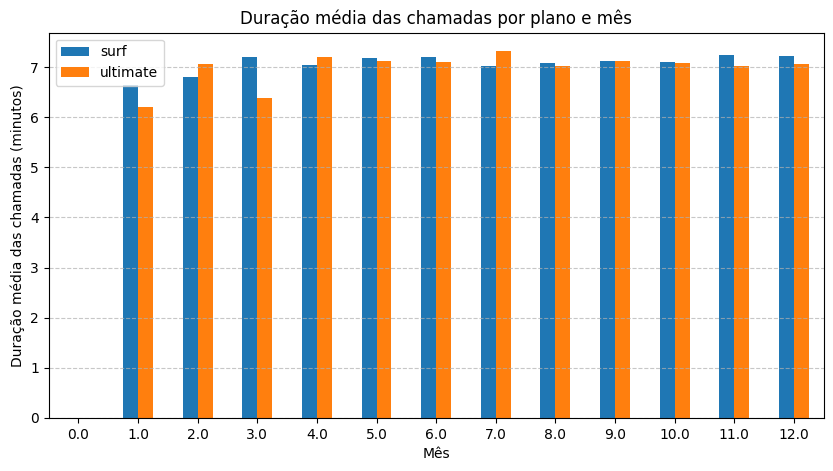

In [51]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

#Calculo da duracao média das chamadas
df_agreed_4['call_average'] = df_agreed_4['total_duration'] / df_agreed_4['amount_calls']
#Filtro das colunas que interessam
df_agreed_7 = df_agreed_4[['plan','call_average','month']]
df_agreed_8 = df_agreed_7.groupby(by=['month','plan']).mean() 

#Construção do gráfico
df_agreed_8.unstack()['call_average'].plot(kind='bar',figsize=(10,5))

plt.title('Duração média das chamadas por plano e mês')
plt.xlabel('Mês')
plt.ylabel ('Duração média das chamadas (minutos)')
plt.legend()
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

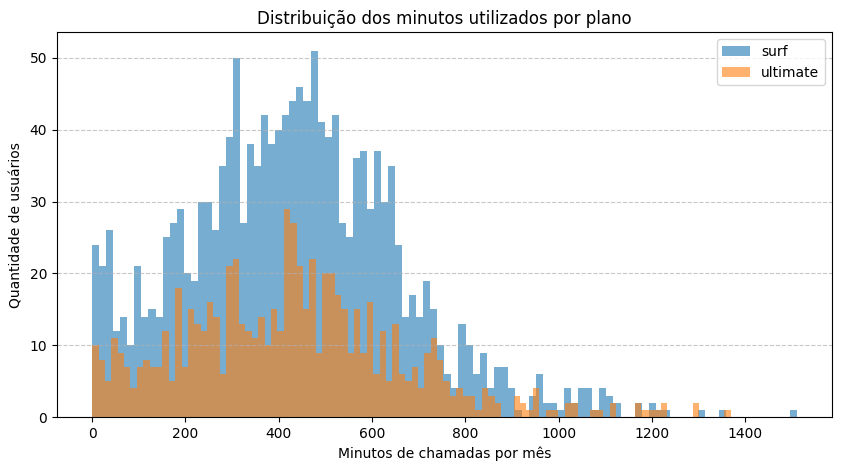

In [52]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
df_agreed_9 = df_agreed_4[['user_id','month','total_duration','plan']]


#Construção do histograma - Plota os dois planos no mesmo gráfico

plt.figure(figsize=(10,5))

plt.hist(df_agreed_9[df_agreed_9['plan'] == 'surf']['total_duration'], bins=100, alpha=0.6, label='surf')
plt.hist(df_agreed_9[df_agreed_9['plan'] == 'ultimate']['total_duration'], bins=100, alpha=0.6, label='ultimate')

plt.title('Distribuição dos minutos utilizados por plano')
plt.xlabel('Minutos de chamadas por mês')
plt.ylabel('Quantidade de usuários')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [53]:
# Calcule a média e a variância da duração mensal das chamadas

print("=== ESTATÍSTICAS DA DURAÇÃO MENSAL DAS CHAMADAS ===\n")

# Agrupar por plano e calcular estatísticas
stats_por_plano = df_agreed_4.groupby('plan')['total_duration'].agg(['mean', 'var'])

print("Média e Variância por plano:")
print(stats_por_plano)

print("\n=== DETALHAMENTO ===")
for plano in ['surf', 'ultimate']:
    dados_plano = df_agreed_4[df_agreed_4['plan'] == plano]['total_duration']
    media = dados_plano.mean()
    variancia = dados_plano.var()
    
    print(f"\nPlano {plano.upper()}:")
    print(f"  Média: {media:.2f} minutos/mês")
    print(f"  Variância: {variancia:.2f}")
    print(f"  Desvio padrão: {dados_plano.std():.2f} minutos")


=== ESTATÍSTICAS DA DURAÇÃO MENSAL DAS CHAMADAS ===

Média e Variância por plano:
                mean           var
plan                              
surf      433.147078  53630.967429
ultimate  431.048679  57666.609048

=== DETALHAMENTO ===

Plano SURF:
  Média: 433.15 minutos/mês
  Variância: 53630.97
  Desvio padrão: 231.58 minutos

Plano ULTIMATE:
  Média: 431.05 minutos/mês
  Variância: 57666.61
  Desvio padrão: 240.14 minutos


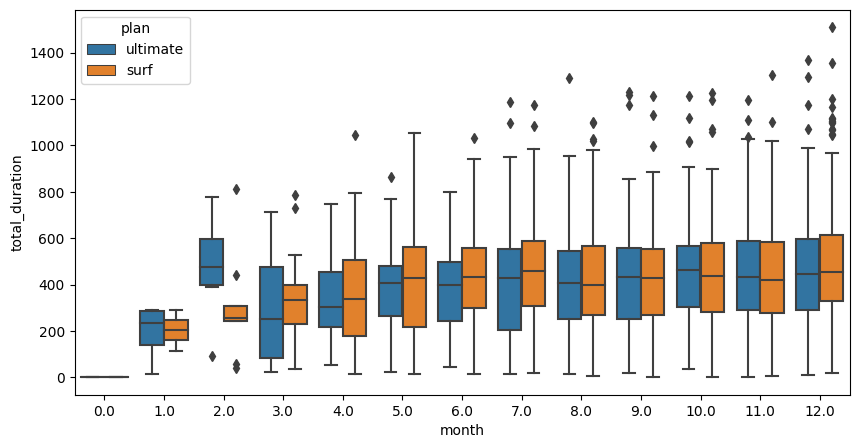

In [54]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='total_duration', data=df_agreed_4, hue='plan')
plt.show()

1 - Médias e medianas semelhantes

* A média de minutos mensais é praticamente igual nos dois planos

2 - Maior variabilidade no plano ultimate

* O plano ultimate tem variância e desvio padrão maiores, isso significa que o uso de minutos entre os clientes ultimate é mais disperso

3- Outliers

* Ambos os planos tem outliers, nesse caso, clientes que falam muito mais que o normal

4 - Conclusão

* Uso  médio é praticamente igual entre os planos
* Variabilidade um pouco maior no plano ultimate
* Os outliers podem indicar usuários corporativos.

### Mensagens

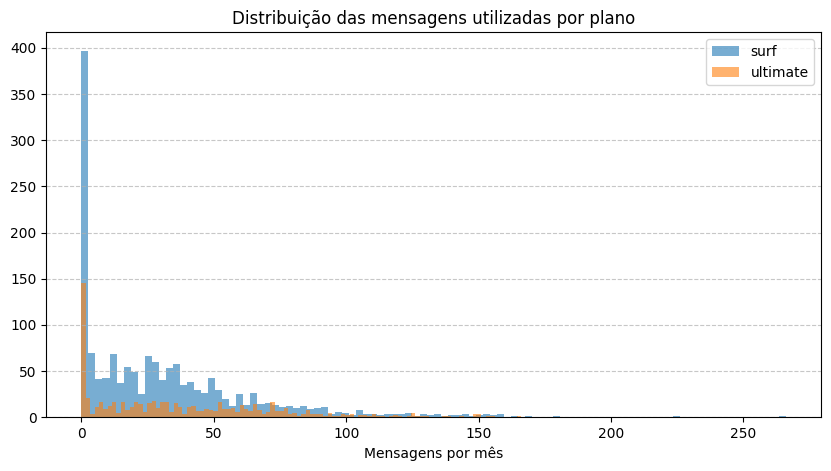

In [55]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
df_agreed_10 = df_agreed_4[['month','amount_messages','plan']]
df_agreed_10

#Construção do histograma - Plota os dois planos no mesmo gráfico
plt.figure(figsize=(10,5))

plt.hist(df_agreed_10[df_agreed_10['plan'] == 'surf']['amount_messages'], bins=100, alpha=0.6, label='surf')
plt.hist(df_agreed_10[df_agreed_10['plan'] == 'ultimate']['amount_messages'], bins=100, alpha=0.6, label='ultimate')

plt.title('Distribuição das mensagens utilizadas por plano')
plt.xlabel('Mensagens por mês')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Internet

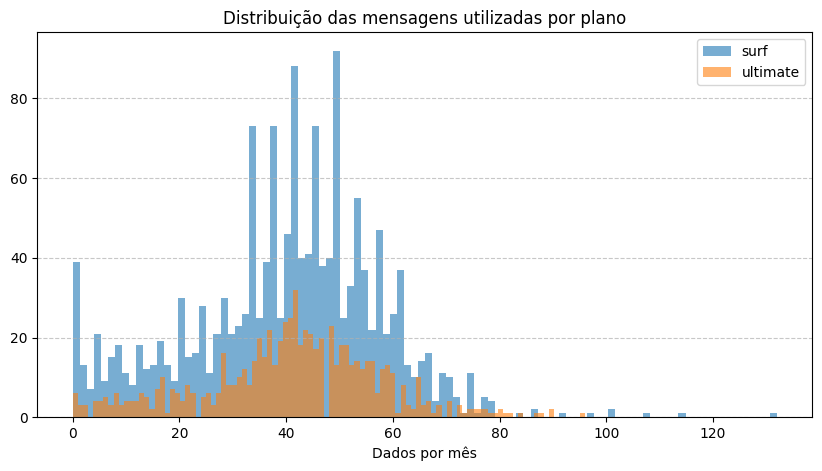

In [56]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
df_agreed_11 = df_agreed_4[['month','gb_used','plan']]
df_agreed_11

#Construção do histograma - Plota os dois planos no mesmo gráfico
plt.figure(figsize=(10,5))

plt.hist(df_agreed_11[df_agreed_11['plan'] == 'surf']['gb_used'], bins=100, alpha=0.6, label='surf')
plt.hist(df_agreed_11[df_agreed_11['plan'] == 'ultimate']['gb_used'], bins=100, alpha=0.6, label='ultimate')

plt.title('Distribuição das mensagens utilizadas por plano')
plt.xlabel('Dados por mês')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Atravéz do histograma acima, percebemos que:

1 - Tanto usuários do plano surf, quanto do plano ultimate consomem entre 30 e 60 GB por mês

## Receita

In [57]:
print("=== ESTATÍSTICAS DAS RECEITAS DE CADA PLANO ===\n")

df_agreed_12 = df_agreed_5[['plan','mensalidade']]
print(df_agreed_12.groupby(by='plan').sum())
print(df_agreed_12.groupby(by='plan').count())
print(df_agreed_12.groupby(by='plan').mean())

=== ESTATÍSTICAS DAS RECEITAS DE CADA PLANO ===

          mensalidade
plan                 
surf        436493.92
ultimate    119504.00
          mensalidade
plan                 
surf             1557
ultimate          719
          mensalidade
plan                 
surf       280.342916
ultimate   166.208623


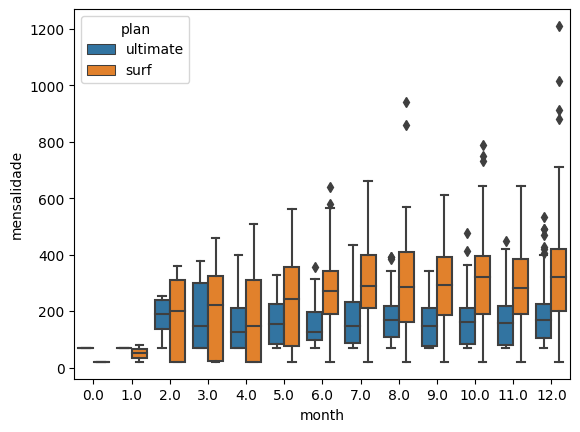

In [67]:
import seaborn as sns

sns.boxplot(data=df_agreed_5, x="month", y='mensalidade', hue="plan")
plt.show()

* Receita total: Surf gera mais receita total (3,5x mais)
* Volume de usuários: Surf tem mais usuários ativos (2x mais)
* Receita por usuário: Surf gera mais receita por usuário ($114 a mais por mês)

## Teste hipóteses estatísticas

Hipótese nula: A receita média dos usuários dos planos surf e ultimate são IGUAIS.

Hipótese alternativa: A receita média dos usuários dos planos surf e ultimate são DIFERENTES.

In [58]:
#Separando a receita mensal de cada plano
mensalidade_ultimate = df_agreed_5[df_agreed_5['plan'] == 'ultimate']['mensalidade']
mensalidade_surf = df_agreed_5[df_agreed_5['plan'] == 'surf']['mensalidade']

In [59]:
#Comparando as variâncias
mensalidade_ultimate.var(), mensalidade_surf.var()

(7566.672293226819, 26287.42952336888)

In [60]:
# Teste
alpha = 0.05

results = st.ttest_ind(mensalidade_ultimate, mensalidade_surf, equal_var=False)
print('valor-p: ', results.pvalue)

if results.pvalue < alpha:
    print('Rejeitamos hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')

valor-p:  1.1471954121156085e-95
Rejeitamos hipótese nula.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

Hipótese nula: A receita média dos usuários da área de NY-NJ são IGUAIS das demais regiões.

Hipótese alternativa: A receita média dos usuários da área de NY-NJ são DIFERENTES das demais regiões.

In [61]:
df_agreed_13 = df_agreed_5[['plan','city','mensalidade']]

#Cálculo da média de mensalidade de cada plano para moradores de NY-NJ
pesquisa_1 = df_agreed_13[df_agreed_13['city'].str.contains('ny-nj')]

#Cálculo da média de mensalidade de cada plano para moradores diferentes de NY-NJ
pesquisa_2 = df_agreed_13[~df_agreed_13['city'].str.contains('ny-nj')]

In [62]:
#Comparando as variâncias
pesquisa_1.var(), pesquisa_2.var()

(mensalidade    21249.600635
 dtype: float64,
 mensalidade    23491.789239
 dtype: float64)

In [72]:
# Teste
alpha = 0.05

equal_var = (pesquisa_1.var() == pesquisa_2.var())[0]
results_1 = st.ttest_ind(pesquisa_1['mensalidade'],pesquisa_2['mensalidade'], equal_var = equal_var)
print('valor-p: ', results_1.pvalue)

if results_1.pvalue < alpha:
    print('Rejeitamos hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')

valor-p:  0.0072176149346683625
Rejeitamos hipótese nula.


## Conclusão geral

* Há uma certa diferença entre a receita média dos planos surf e ultimate.
* O plano surf têm muito mais usuários que o plano ultimate.
* Usuários do plano surf costumam utilizar mais minutos, dados e mensagens disponíveis no plano, assim pagando uma mensalidade maior.